# Re-DocRED Operational Anchor — Dataset Demo

**Artifact:** *Re-DocRED Anchor: 236-doc triple-schema corpus with entities, evidence & 4 CV folds*

This notebook demonstrates the **deterministic data-preparation pipeline** (`data.py`) behind the
Re-DocRED operational-anchor dataset — the single chosen corpus for the label-free FDR-gating /
neuro-symbolic **text → first-order-logic** hypothesis.

The full builder standardizes all **4053** Re-DocRED documents (Tan et al., EMNLP 2022) into a shared
schema: reconstructed prose with **exact character offsets**, a full entity inventory, gold
`(head, relation, tail)` triples with sentence-level evidence, **17 per-document "S5" features**, and a
balanced 4-fold *confirmatory / pilot / reserve* cross-validation split.

Here we load a **curated 16-document subset** (all 4 folds × all 3 split roles) and re-run the core
builder functions **verbatim** to prove the dataset is fully regenerable:

1. **Detokenization** → reconstructed prose + exact sentence char-offsets
2. **Entity char-spans** + canonical-name resolution
3. **S5 feature** re-derivation (all 17 features)
4. **Primary fold** assignment (dominant-entity-type → 4 clusters)
5. **Secondary k-means** clustering
6. **Eligibility filter** + balanced *even-pick* selection
7. **Row JSON-Schema** validation (the dataset contract)

Each step recomputes a quantity from raw fields and checks it **exactly matches** the value stored in
the dataset — i.e. `uv run data.py` reproduces these rows byte-for-byte.


In [1]:
# --- Dependency install (works on Colab AND local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All of these are pre-installed on Colab. On Colab we MUST NOT reinstall them (it corrupts the
# pre-loaded C extensions); locally we install them at Colab's exact versions to mirror the env.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'matplotlib==3.10.0', 'pandas==2.2.2', 'jsonschema==4.26.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports copied from data.py (logging/CLI-only imports omitted for the notebook) ---
import json
from collections import Counter

import numpy as np
import jsonschema
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# extra imports for the demo (summary table + plots)
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub raw URL first, local file as fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-1/dataset-2/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

meta = data["metadata"]
all_examples = data["datasets"][0]["examples"]
print("dataset:", meta["name"])
print("source :", meta["source"][:70], "...")
print("curated demo subset:", len(all_examples), "documents")
print("folds present :", sorted({e["metadata_fold"] for e in all_examples}))
print("roles present :", sorted({e["metadata_split_role"] for e in all_examples}))

dataset: Re-DocRED Operational Anchor (label-free FDR-gating)
source : Re-DocRED (Tan, Xu, Bing et al., 'Revisiting DocRED — Addressing the F ...
curated demo subset: 16 documents
folds present : ['cluster_LOC', 'cluster_MISC', 'cluster_ORG', 'cluster_PER']
roles present : ['confirmatory', 'pilot', 'reserve']


## Configuration

All tunable knobs live here. They start small for a fast demo; the commented values are what the full
`data.py` run uses over the entire 4053-document Re-DocRED corpus. The schema constants
(`ENTITY_TYPES`, `TYPE_PRIORITY`) are copied verbatim from `data.py` and are **not** tunable.

In [5]:
# === Tunable demo parameters (start small; scale toward the full-run values noted) ===
N_DEMO_EXAMPLES = 16        # docs to process from the curated subset (full data.py: all 4053)

KMEANS_K   = 4              # secondary k-means clusters       (full data.py: 5)
KMEANS_RS  = 42             # k-means random_state             (full data.py: 42)
TOP_REL_K  = 20             # top-K relations in feature vector (full data.py: 20)
SEED       = 20240617       # global reproducibility seed       (full data.py: 20240617)

# balanced selection sizes PER FOLD for the even_pick demo
# (full data.py uses 38 / 9 / 12 across 4053 docs -> 152 / 36 / 48 emitted rows)
DEMO_N_CONF, DEMO_N_PILOT, DEMO_N_RESERVE = 2, 1, 1

# === Fixed schema constants (verbatim from data.py — NOT tunable) ===
ENTITY_TYPES  = ["PER", "ORG", "LOC", "TIME", "NUM", "MISC"]
TYPE_PRIORITY = {"PER": 0, "ORG": 1, "LOC": 2, "MISC": 3, "TIME": 4, "NUM": 5}

# the working set for the rest of the notebook
examples = all_examples[:N_DEMO_EXAMPLES]
print(f"processing {len(examples)} documents")

processing 16 documents


## 1. Detokenization → reconstructed prose + exact char-offsets

Re-DocRED ships documents as **lists of token lists** (one list per sentence). `data.py` rebuilds the
human-readable prose with a deterministic detokenizer that also records, for every token, its exact
half-open `[start, end)` character span. Joining sentences with a single space yields the document
`input` text and the per-sentence character offsets.

Below, `detokenize` and `reconstruct` are copied **verbatim** from `data.py`. We re-run them on each
document's stored tokens and confirm the output matches the stored `input` and `sent_char_offsets`
exactly.

In [6]:
# --- copied verbatim from data.py ---
NO_SPACE_BEFORE = {
    ",", ".", "!", "?", ";", ":", ")", "]", "}", "%", "''", "”", "’", "…",
    "'s", "'S", "'re", "'ve", "'ll", "'d", "'m", "n't", "N'T", "'t", "'",
}
NO_SPACE_AFTER = {"(", "[", "{", "``", "“", "`", "$", "#"}


def detokenize(tokens):
    """Deterministic detok -> (sentence_string, per-token half-open [start,end) char spans)."""
    s, spans, suppress_next, dq_open = "", [], False, True
    for tok in tokens:
        if s == "":
            sep = ""
        elif suppress_next:
            sep = ""
        elif tok in NO_SPACE_BEFORE:
            sep = ""
        elif tok == '"':
            sep = "" if not dq_open else " "
        else:
            sep = " "
        s += sep
        start = len(s)
        s += tok
        spans.append((start, len(s)))
        if tok in NO_SPACE_AFTER:
            suppress_next = True
        elif tok == '"':
            suppress_next = dq_open
            dq_open = not dq_open
        else:
            suppress_next = False
    return s, spans


def reconstruct(sents):
    sent_strings, per_sent_spans = [], []
    for toks in sents:
        st, sp = detokenize(toks)
        sent_strings.append(st)
        per_sent_spans.append(sp)
    offsets, cur = [], 0
    for st in sent_strings:
        offsets.append(cur)
        cur += len(st) + 1
    return " ".join(sent_strings), offsets, per_sent_spans, sent_strings


# re-run on every demo document and verify it matches the stored fields
ok = 0
for ex in examples:
    text, offsets, per_sent_spans, sent_strings = reconstruct(ex["metadata_sents"])
    assert text == ex["input"], f"text mismatch for {ex['metadata_id']}"
    assert offsets == ex["metadata_sent_char_offsets"], f"offset mismatch for {ex['metadata_id']}"
    ok += 1
print(f"{ok}/{len(examples)} documents: reconstructed prose + sentence char-offsets match EXACTLY")
print()
print("example reconstruction:", examples[0]["metadata_id"])
print(reconstruct(examples[0]["metadata_sents"])[0][:200], "...")

16/16 documents: reconstructed prose + sentence char-offsets match EXACTLY

example reconstruction: redocred_test_477
Mikhail Borisovich Kogan (; September 5, 1893 in Zhitomir, Russian Empire – November 26, 1951 in Moscow, USSR) was a well - known medical doctor, a head of the therapy department of 2nd Moscow Medical ...


## 2. Entity char-spans + canonical-name resolution

Every entity mention carries its token position `pos = [start_tok, end_tok)` within a sentence. The
function `char_span_for` converts that token position into an exact document-level character span using
the sentence offsets + per-token spans from step 1. Separately, `canonical_name` picks each entity's
representative surface form (most frequent mention name, ties broken by length).

We recompute both from the raw mentions and confirm they match the stored `char_span` / `canonical_name`
for every entity.

In [7]:
# --- copied verbatim from data.py ---
def char_span_for(pos, sent_id, offsets, per_sent_spans):
    try:
        spans = per_sent_spans[sent_id]
        s_tok, e_tok = pos[0], pos[1] - 1
        if not (0 <= s_tok < len(spans)) or not (0 <= e_tok < len(spans)):
            return None
        return [offsets[sent_id] + spans[s_tok][0], offsets[sent_id] + spans[e_tok][1]]
    except Exception:  # noqa: BLE001 — char span is convenience; token pos is authoritative
        return None


def canonical_name(mentions):
    c = Counter(m["name"] for m in mentions)
    return max(c.items(), key=lambda kv: (kv[1], len(kv[0])))[0]


span_ok = span_tot = name_ok = name_tot = 0
for ex in examples:
    _, offsets, per_sent_spans, _ = reconstruct(ex["metadata_sents"])
    for ent in ex["metadata_entities"]:
        name_tot += 1
        name_ok += (canonical_name(ent["mentions"]) == ent["canonical_name"])
        for m in ent["mentions"]:
            cs = char_span_for(m["pos"], m["sent_id"], offsets, per_sent_spans)
            span_tot += 1
            span_ok += (cs == m["char_span"])

print(f"char-spans     : {span_ok}/{span_tot} mentions match stored offsets")
print(f"canonical names: {name_ok}/{name_tot} entities match stored canonical_name")

# show a concrete grounded mention
e0 = examples[0]
ent0 = e0["metadata_entities"][0]
a, b = ent0["mentions"][0]["char_span"]
print()
print(f'entity 0 = "{ent0["canonical_name"]}" ({ent0["type"]}), char_span [{a},{b}] -> '
      f'"{e0["input"][a:b]}"')

char-spans     : 380/380 mentions match stored offsets
canonical names: 289/289 entities match stored canonical_name

entity 0 = "Mikhail Borisovich Kogan" (PER), char_span [0,24] -> "Mikhail Borisovich Kogan"


## 3. S5 feature re-derivation (all 17 features)

Each document carries 17 `metadata_features` used as inputs to the planned S5 GAP-regression analysis
(lengths, entity/relation profiles, densities, evidence-gap statistics). The block below is the
feature-computation logic from `data.py`'s `process_document`, applied to the stored raw fields. We
re-derive the full feature dict and check it equals the stored one **exactly** for every document.

In [8]:
# --- feature logic copied from data.py (process_document) ---
def compute_features(ex):
    sents = ex["metadata_sents"]
    text = ex["input"]
    entities = ex["metadata_entities"]
    gold = ex["metadata_gold_triples"]

    total_mentions = sum(e["n_mentions"] for e in entities)
    etype_counts = Counter(e["type"] for e in entities)
    num_words = sum(len(s) for s in sents)
    num_sents, num_entities, num_triples = len(sents), len(entities), len(gold)
    rel_counts = Counter(g["relation_pid"] for g in gold)
    etc = {tp: int(etype_counts.get(tp, 0)) for tp in ENTITY_TYPES}
    dominant = max(ENTITY_TYPES, key=lambda tp: (etc[tp], -TYPE_PRIORITY[tp])) if num_entities else "MISC"
    multi_ev = sum(1 for g in gold if len(g["evidence_sent_ids"]) > 1)
    gaps = [max(g["evidence_sent_ids"]) - min(g["evidence_sent_ids"]) for g in gold if g["evidence_sent_ids"]]
    singletons = sum(1 for e in entities if e["n_mentions"] == 1)
    return {
        "num_words": num_words, "num_chars": len(text), "num_sents": num_sents,
        "num_entities": num_entities, "num_triples": num_triples,
        "num_relation_types_present": len(rel_counts),
        "num_entity_types_present": sum(1 for tp in ENTITY_TYPES if etc[tp] > 0),
        "entity_type_counts": etc, "dominant_entity_type": dominant,
        "relation_pid_counts": dict(rel_counts),
        "avg_mentions_per_entity": (total_mentions / num_entities) if num_entities else 0.0,
        "entity_density": (num_entities / num_words) if num_words else 0.0,
        "mention_density": (total_mentions / num_words) if num_words else 0.0,
        "triple_density": (num_triples / num_sents) if num_sents else 0.0,
        "frac_singleton_entities": (singletons / num_entities) if num_entities else 0.0,
        "frac_multi_evidence_triples": (multi_ev / num_triples) if num_triples else 0.0,
        "max_evidence_sentence_gap": int(max(gaps)) if gaps else 0,
    }


feat_ok = 0
for ex in examples:
    rebuilt = compute_features(ex)
    if rebuilt == ex["metadata_features"]:
        feat_ok += 1
    else:
        diffs = {k: (rebuilt[k], ex["metadata_features"].get(k))
                 for k in rebuilt if rebuilt[k] != ex["metadata_features"].get(k)}
        print(ex["metadata_id"], "FEATURE DIFF:", diffs)
print(f"{feat_ok}/{len(examples)} documents: all 17 S5 features re-derived EXACTLY")

16/16 documents: all 17 S5 features re-derived EXACTLY


## 4. Primary fold assignment (dominant entity type → 4 clusters)

The primary CV scheme assigns each document to one of four folds by its **dominant entity type**
(PER / ORG / LOC, with everything else → MISC). This enables leave-one-cluster-out cross-validation.
`primary_cluster` is copied verbatim; we re-derive the dominant type from the entity-type counts and
confirm the resulting fold matches `metadata_fold`.

In [9]:
# --- copied verbatim from data.py ---
def primary_cluster(dominant):
    return {"PER": "cluster_PER", "ORG": "cluster_ORG", "LOC": "cluster_LOC"}.get(dominant, "cluster_MISC")


fold_ok = 0
for ex in examples:
    etc = ex["metadata_features"]["entity_type_counts"]
    dominant = max(ENTITY_TYPES, key=lambda tp: (etc[tp], -TYPE_PRIORITY[tp]))
    assert dominant == ex["metadata_features"]["dominant_entity_type"]
    fold_ok += (primary_cluster(dominant) == ex["metadata_fold"])
print(f"{fold_ok}/{len(examples)} documents: primary fold re-derived correctly")

from collections import Counter as _C
print("fold distribution:", dict(_C(e["metadata_fold"] for e in examples)))

16/16 documents: primary fold re-derived correctly
fold distribution: {'cluster_PER': 4, 'cluster_ORG': 4, 'cluster_LOC': 4, 'cluster_MISC': 4}


## 5. Secondary k-means clustering

A secondary clustering scheme runs k-means over a feature vector built from the **normalized
entity-type histogram + top-K relation profile + standardized length**. The vector-building +
`StandardScaler` + `KMeans` block is copied from `data.py`'s `main()`.

Note: k-means labels are *population-dependent* — here we cluster only the 16-document demo subset, so
the labels are demo-local and not expected to equal the stored `metadata_kmeans_cluster` (which was fit
over all 4053 docs). The point is that the **feature-vector construction** reproduces exactly.

In [10]:
# --- copied from data.py main(): build feature vectors, scale, k-means ---
rows = examples
corpus_rel = Counter()
for r in rows:
    corpus_rel.update(r["metadata_features"]["relation_pid_counts"])
top_rels = [p for p, _ in corpus_rel.most_common(TOP_REL_K)]
rel_index = {p: i for i, p in enumerate(top_rels)}

feats = []
for r in rows:
    f = r["metadata_features"]
    et = np.array([f["entity_type_counts"][tp] for tp in ENTITY_TYPES], dtype=float)
    et = et / et.sum() if et.sum() else et
    rv = np.zeros(len(top_rels)); tot = 0
    for p, c in f["relation_pid_counts"].items():
        if p in rel_index:
            rv[rel_index[p]] += c; tot += c
    if tot:
        rv = rv / tot
    feats.append(np.concatenate([et, rv, [f["num_words"]]]))

Xs = StandardScaler().fit_transform(np.array(feats))
k_eff = min(KMEANS_K, len(rows))  # guard: k cannot exceed sample count in the small demo
km = KMeans(n_clusters=k_eff, random_state=KMEANS_RS, n_init=10).fit(Xs)
# keep labels in a side dict (do NOT mutate the row dicts — they must still pass the strict
# additionalProperties=False schema validated in section 7)
demo_kmeans = {r["metadata_id"]: int(lab) for r, lab in zip(rows, km.labels_)}

print(f"feature vector dim: {Xs.shape[1]}  (6 entity-type + {len(top_rels)} relation + 1 length)")
print(f"k-means (k={k_eff}) demo-local labels:", [int(l) for l in km.labels_])

feature vector dim: 27  (6 entity-type + 20 relation + 1 length)
k-means (k=4) demo-local labels: [0, 0, 0, 2, 1, 1, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0]


## 6. Eligibility filter + balanced *even-pick* selection

Documents qualify only if `80 ≤ num_words ≤ 400`, `num_entities ≥ 4`, and `num_triples ≥ 5`. Within
each fold the builder uses `even_pick` (an evenly-spread index sample over the length-sorted pool) to
draw a balanced *confirmatory / pilot / reserve* split. Both functions are copied verbatim; we run the
selection over the demo subset at the small per-fold sizes from the config cell.

In [11]:
# --- copied verbatim from data.py ---
def even_pick(items, n):
    if n <= 0 or not items:
        return []
    if n >= len(items):
        return list(items)
    idx = sorted(set(int(round(x)) for x in np.linspace(0, len(items) - 1, n)))
    i = 0
    while len(idx) < n and i < len(items):
        if i not in idx:
            idx.append(i)
        i += 1
    return [items[i] for i in sorted(idx)[:n]]


# --- eligibility logic copied from data.py main() ---
def eligible(r):
    f = r["metadata_features"]
    return 80 <= f["num_words"] <= 400 and f["num_entities"] >= 4 and f["num_triples"] >= 5


elig = [r for r in rows if eligible(r)]
print(f"eligible: {len(elig)}/{len(rows)} documents pass 80<=words<=400, >=4 entities, >=5 triples")

clusters = ["cluster_PER", "cluster_ORG", "cluster_LOC", "cluster_MISC"]
by_cluster = {c: [r for r in elig if r["metadata_fold"] == c] for c in clusters}
for c in clusters:
    # note: emitted rows key the id as "metadata_id" (data.py keys raw rows as "id")
    pool = sorted(by_cluster[c], key=lambda r: (r["metadata_features"]["num_words"], r["metadata_id"]))
    conf = even_pick(pool, DEMO_N_CONF)
    rem = [r for r in pool if r["metadata_id"] not in {x["metadata_id"] for x in conf}]
    pilot = even_pick(rem, DEMO_N_PILOT)
    rem2 = [r for r in rem if r["metadata_id"] not in {x["metadata_id"] for x in pilot}]
    reserve = even_pick(rem2, DEMO_N_RESERVE)
    print(f"  {c}: pool={len(pool)} -> conf={len(conf)} pilot={len(pilot)} reserve={len(reserve)}")

eligible: 16/16 documents pass 80<=words<=400, >=4 entities, >=5 triples
  cluster_PER: pool=4 -> conf=2 pilot=1 reserve=1
  cluster_ORG: pool=4 -> conf=2 pilot=1 reserve=1
  cluster_LOC: pool=4 -> conf=2 pilot=1 reserve=1
  cluster_MISC: pool=4 -> conf=2 pilot=1 reserve=1


## 7. Row JSON-Schema validation (the dataset contract)

Every emitted row is validated against a custom Draft-07 JSON-Schema — this is the contract every
downstream system relies on. `build_row_schema` is copied verbatim from `data.py`; we validate each
loaded demo row and confirm zero errors.

In [12]:
# --- copied verbatim from data.py ---
def build_row_schema():
    mention = {"type": "object", "required": ["name", "sent_id", "pos", "char_span"], "additionalProperties": False,
               "properties": {"name": {"type": "string"}, "sent_id": {"type": "integer", "minimum": 0},
                              "pos": {"type": "array", "items": {"type": "integer"}, "minItems": 2, "maxItems": 2},
                              "char_span": {"oneOf": [{"type": "null"},
                                                      {"type": "array", "items": {"type": "integer"},
                                                       "minItems": 2, "maxItems": 2}]}}}
    entity = {"type": "object", "required": ["entity_id", "type", "canonical_name", "n_mentions", "mentions"],
              "additionalProperties": False,
              "properties": {"entity_id": {"type": "integer", "minimum": 0},
                             "type": {"enum": ENTITY_TYPES}, "canonical_name": {"type": "string"},
                             "n_mentions": {"type": "integer", "minimum": 1},
                             "mentions": {"type": "array", "minItems": 1, "items": mention}}}
    triple = {"type": "object", "additionalProperties": False,
              "required": ["head_id", "head_name", "head_type", "relation_pid", "relation_name",
                           "tail_id", "tail_name", "tail_type", "evidence_sent_ids", "evidence_text"],
              "properties": {"head_id": {"type": "integer", "minimum": 0},
                             "head_name": {"type": ["string", "null"]}, "head_type": {"type": ["string", "null"]},
                             "relation_pid": {"type": "string", "pattern": "^P[0-9]+$"},
                             "relation_name": {"type": "string"}, "tail_id": {"type": "integer", "minimum": 0},
                             "tail_name": {"type": ["string", "null"]}, "tail_type": {"type": ["string", "null"]},
                             "evidence_sent_ids": {"type": "array", "items": {"type": "integer"}},
                             "evidence_text": {"type": "array", "items": {"type": "string"}}}}
    return {
        "$schema": "http://json-schema.org/draft-07/schema#", "type": "object", "additionalProperties": False,
        "required": ["input", "output", "metadata_fold", "metadata_id", "metadata_split_origin",
                     "metadata_orig_index", "metadata_split_role", "metadata_is_confirmatory",
                     "metadata_is_pilot", "metadata_is_reserve", "metadata_kmeans_cluster",
                     "metadata_cluster_scheme", "metadata_seed", "metadata_sents", "metadata_sent_char_offsets",
                     "metadata_entities", "metadata_gold_triples", "metadata_features", "metadata_gold_caveat",
                     "metadata_title"],
        "properties": {
            "input": {"type": "string", "minLength": 1}, "output": {"type": "string", "minLength": 1},
            "metadata_fold": {"enum": ["cluster_PER", "cluster_ORG", "cluster_LOC", "cluster_MISC"]},
            "metadata_id": {"type": "string", "pattern": "^redocred_(train|dev|test)_[0-9]+$"},
            "metadata_title": {"type": "string"}, "metadata_split_origin": {"enum": ["train", "dev", "test"]},
            "metadata_orig_index": {"type": "integer", "minimum": 0},
            "metadata_split_role": {"enum": ["confirmatory", "pilot", "reserve"]},
            "metadata_is_confirmatory": {"type": "boolean"}, "metadata_is_pilot": {"type": "boolean"},
            "metadata_is_reserve": {"type": "boolean"}, "metadata_kmeans_cluster": {"type": "integer", "minimum": 0},
            "metadata_cluster_scheme": {"type": "string"}, "metadata_seed": {"type": "integer"},
            "metadata_sents": {"type": "array", "items": {"type": "array", "items": {"type": "string"}}},
            "metadata_sent_char_offsets": {"type": "array", "items": {"type": "integer"}},
            "metadata_entities": {"type": "array", "minItems": 1, "items": entity},
            "metadata_gold_triples": {"type": "array", "items": triple},
            "metadata_features": {"type": "object", "additionalProperties": True,
                                  "required": ["num_words", "num_chars", "num_sents", "num_entities", "num_triples",
                                               "num_relation_types_present", "num_entity_types_present",
                                               "entity_type_counts", "dominant_entity_type", "relation_pid_counts",
                                               "avg_mentions_per_entity", "entity_density", "mention_density",
                                               "triple_density", "frac_singleton_entities",
                                               "frac_multi_evidence_triples", "max_evidence_sentence_gap"]},
            "metadata_gold_caveat": {"type": "string"},
        },
    }


validator = jsonschema.Draft7Validator(build_row_schema())
nerr = 0
for ex in examples:
    for e in sorted(validator.iter_errors(ex), key=lambda e: list(e.path))[:3]:
        print(f"{ex.get('metadata_id')}: {list(e.path)} -> {e.message}")
        nerr += 1
print(f"all {len(examples)} rows validated against the custom row schema; {nerr} errors")

all 16 rows validated against the custom row schema; 0 errors


## Results — summary table, reasoning trace & feature plots

A per-document summary table, one example's gold triples rendered as an **auditable reasoning
trace-graph** (head —[relation]→ tail, with evidence sentences), and feature distributions across the
four CV folds.

In [13]:
# ---- per-document summary table ----
summ = pd.DataFrame([{
    "id": e["metadata_id"],
    "fold": e["metadata_fold"].replace("cluster_", ""),
    "role": e["metadata_split_role"],
    "words": e["metadata_features"]["num_words"],
    "sents": e["metadata_features"]["num_sents"],
    "ents": e["metadata_features"]["num_entities"],
    "triples": e["metadata_features"]["num_triples"],
    "triple_density": round(e["metadata_features"]["triple_density"], 2),
    "frac_multi_ev": round(e["metadata_features"]["frac_multi_evidence_triples"], 2),
    "kmeans": demo_kmeans.get(e["metadata_id"]),
} for e in examples])
print(summ.to_string(index=False))

# ---- one auditable reasoning trace-graph (the goal: human-readable logical paths) ----
ex = examples[0]
print()
print(f'TRACE-GRAPH for {ex["metadata_id"]} ("{ex["metadata_title"]}")')
for g in ex["metadata_gold_triples"][:6]:
    print(f'  ({g["head_name"]}) -[{g["relation_name"]}]-> ({g["tail_name"]})  '
          f'evidence sents={g["evidence_sent_ids"]}')

                 id fold         role  words  sents  ents  triples  triple_density  frac_multi_ev  kmeans
  redocred_test_477  PER confirmatory    129      4    16       24            6.00           0.00       0
  redocred_test_445  ORG confirmatory    129      5    13       17            3.40           0.29       0
   redocred_dev_459  LOC confirmatory    129      6    14       19            3.17           0.58       0
   redocred_dev_260 MISC confirmatory    129      5    12       26            5.20           0.00       2
   redocred_test_82  PER confirmatory    397     11    24       53            4.82           0.00       1
redocred_train_1151  ORG confirmatory    384     16    25       21            1.31           0.19       1
 redocred_train_136  LOC confirmatory    397     13    27       25            1.92           0.32       0
redocred_train_2094 MISC confirmatory    400     11    23       36            3.27           0.19       2
redocred_train_2245  PER        pilot    129  

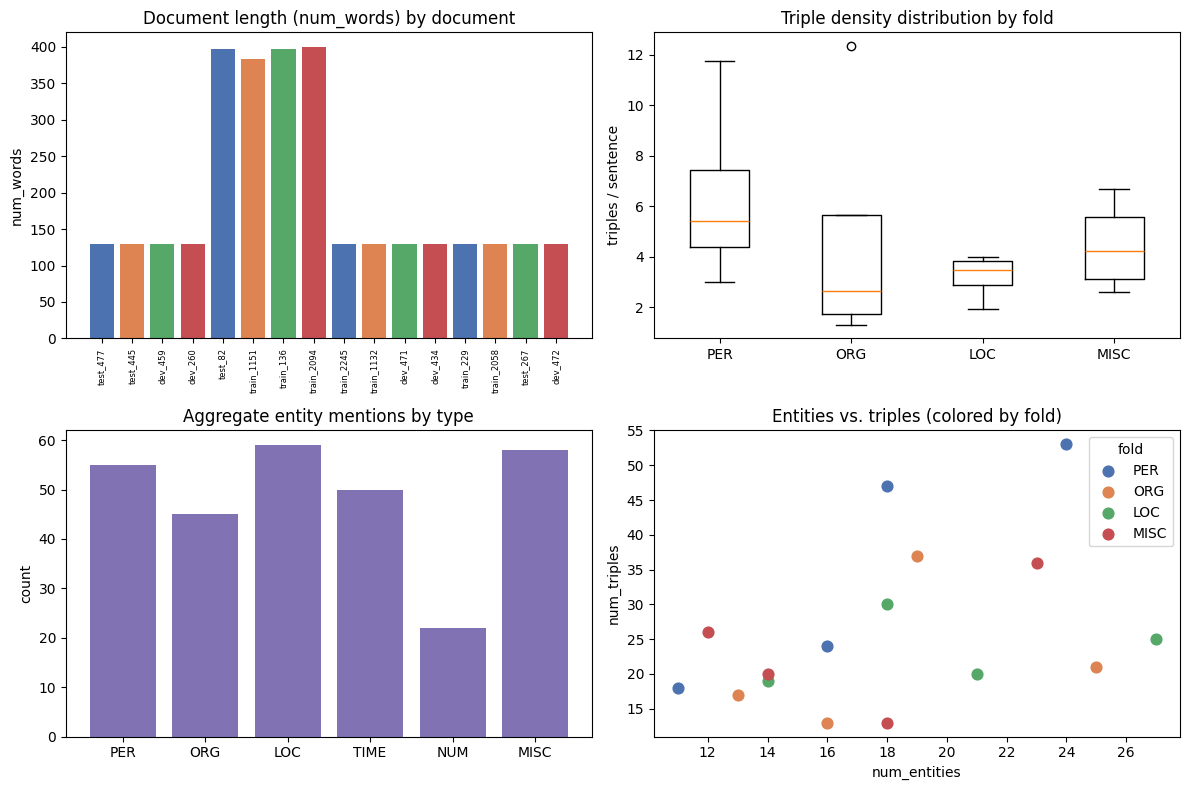

demo subset covers 59 distinct relations and 6/6 entity types across 16 documents


In [14]:
# ---- feature distributions across the 4 CV folds ----
folds_order = ["PER", "ORG", "LOC", "MISC"]
present = [f for f in folds_order if f in set(summ["fold"])]
colors = {"PER": "#4C72B0", "ORG": "#DD8452", "LOC": "#55A868", "MISC": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) num_words by document, colored by fold
ax = axes[0, 0]
ax.bar(summ["id"].str.replace("redocred_", ""), summ["words"],
       color=[colors[f] for f in summ["fold"]])
ax.set_title("Document length (num_words) by document")
ax.set_ylabel("num_words"); ax.tick_params(axis="x", rotation=90, labelsize=6)

# (b) triple_density by fold (boxplot)
ax = axes[0, 1]
ax.boxplot([summ[summ["fold"] == f]["triple_density"] for f in present], tick_labels=present)
ax.set_title("Triple density distribution by fold")
ax.set_ylabel("triples / sentence")

# (c) aggregate entity-type counts
ax = axes[1, 0]
agg = Counter()
for e in examples:
    for tp, c in e["metadata_features"]["entity_type_counts"].items():
        agg[tp] += c
tps = [t for t in ENTITY_TYPES if agg[t] > 0]
ax.bar(tps, [agg[t] for t in tps], color="#8172B3")
ax.set_title("Aggregate entity mentions by type"); ax.set_ylabel("count")

# (d) entities vs triples scatter, colored by fold
ax = axes[1, 1]
for f in present:
    sub = summ[summ["fold"] == f]
    ax.scatter(sub["ents"], sub["triples"], label=f, color=colors[f], s=60)
ax.set_xlabel("num_entities"); ax.set_ylabel("num_triples")
ax.set_title("Entities vs. triples (colored by fold)"); ax.legend(title="fold")

plt.tight_layout()
plt.show()

# ---- coverage summary ----
covered_rels = {g["relation_pid"] for e in examples for g in e["metadata_gold_triples"]}
covered_types = {en["type"] for e in examples for en in e["metadata_entities"]}
print(f"demo subset covers {len(covered_rels)} distinct relations and "
      f"{len(covered_types)}/6 entity types across {len(examples)} documents")